### 가중치 감쇠
- 원래 손실함수와 함께 L2 노름을 같이 최소화하도록 하여 모델의 학습을 방해하는 형태로 

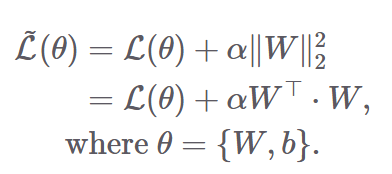
- 학습을 진행하면 (1)번 텀을 최소화함 $\to$ 손실을 줄이는 가중치(W)는 커지게 되므로 L2값인 (2)번 텀은 커지게 되어 전체 손실이 최소화되는 것을 방해함
  - 일반적으로 오버피팅은 가중치가 너무 커져서 발생함 $\to$ 큰 가중치에 큰 패널티 부과하여 오버피팅 방해함
  - 가중치에 loss를 살짝 더해 학습을 방해
  - 뉴런과 뉴런 사이의 가중치가 너무 과도하게 커서 오버피팅이 발생
- 파이토치에서는 optimizer의 설정으로 구현

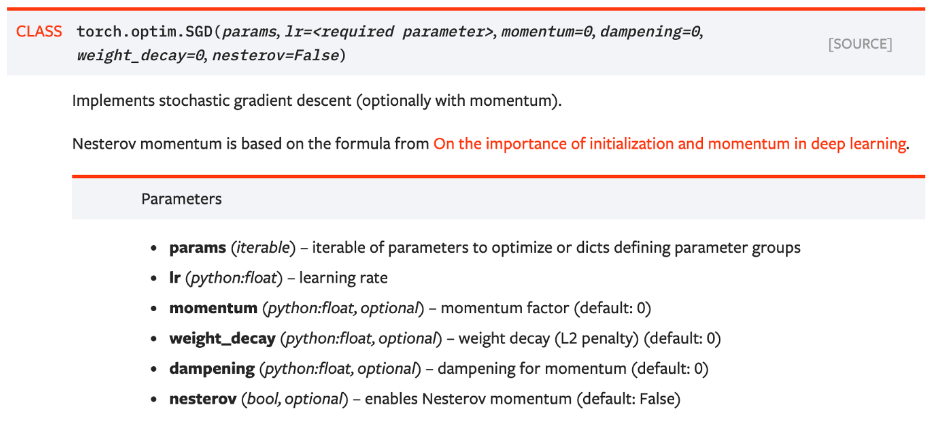

(GPT)
- 모델의 가중치가 지나치게 커지는 것을 방지하기 위해 가중치를 일정 비율로 줄이는 정규화 기법
- 목적
  - 과적합(오버피팅) 방지: 큰 가중치는 훈련 데이터에 과도하게 맞춰지는 경향이 있음 $\to$ 이를 줄여 모델이 일반화되도록 함
  - 학습 안정화: 가중치 폭주(exploding weight)를 방지
  - 너무 복잡한 모델 억제: 작은 가중치를 갖는 모델이 더 안정적이고 단순함

### 데이터 증강
- 데이터의 핵심 특징은 간직한 채, 노이즈를 더하여 데이터셋을 확장하는 방법

### 이미지 증강 기법
- salt & pepper 노이즈 추가
- 회전, 이동 뒤집기
- 생성 모델을 활용한 데이터 증강

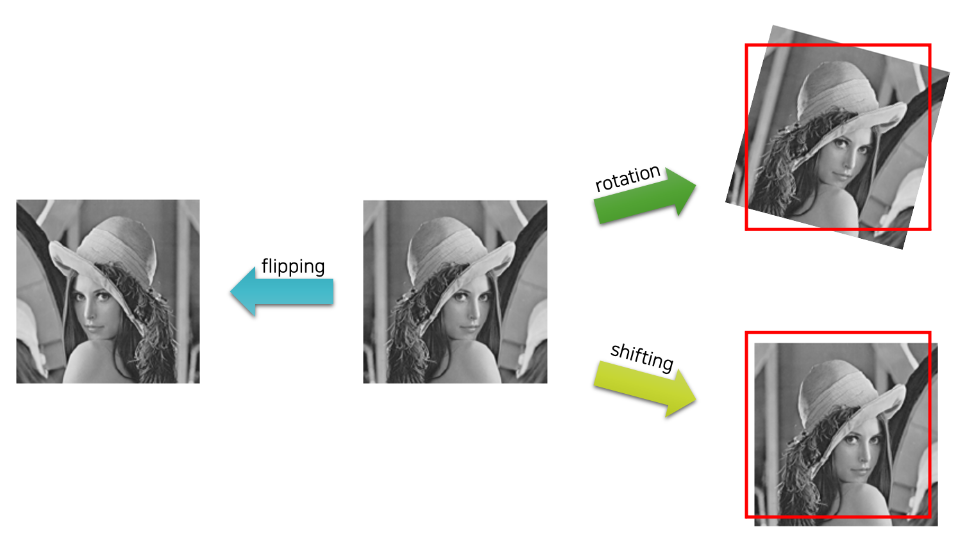
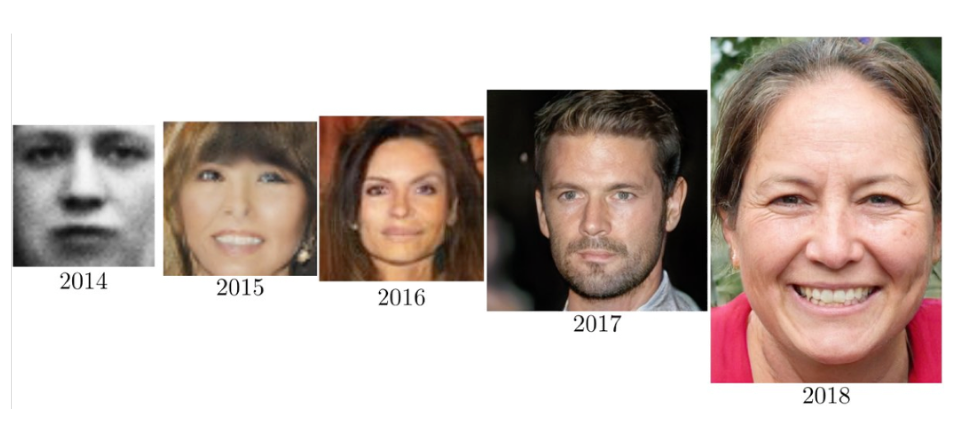

### 텍스트 증강 기법
- 어순 변화나 단어의 변화에 민감하기 때문에 이미지만큼 데이터 증강이 자유롭지 못함
- 단어 생략
  - 나는 학교에 가는 것을 좋아한다
  - 나는 ____ 가는 것을 좋아한다(빈 칸을 텍스트로 넣어주는 것이 아니라 빠진 채로 문장이 들어감)
- 단어 교환
  - 나는 학교에 가는 것을 좋아한다
  - 나는 좋아한다 가는 것을 학교에
- 단어 이동
  - 나는 학교에 가는 것을 좋아한다
  - 나는 가는 것을 좋아한다 학교에

### 데이터 증강의 장점과 한계
- 장점: 신경망의 구조나 학습 방법의 수정이 필요없음, 공짜로 데이터를 더 얻는 느낌
- 단점: 새로운 지식을 배우는 것이 아니라 최적화를 수월하게 수행하도록 함을 의미
  - 백인 얼굴을 증강한다고 흑인 얼굴을 인식하는 것은 아님

### 드롭아웃
- 데이터 증강 기법 $\to$ 신경망의 입력 또는 출력 위치에 노이즈를 추가하는 것으로 볼 수 있음
- 드롭아웃 $\to$ 신경망의 중간에 노이즈 추가 효과
  - 임의의 노드를 일정 확률로 드롭해서 학습에 참여하지 않도록 하는 방법
- 히든 레이어 몇 개를 동작을 안하게 하는 것(랜덤하게)
  - 드랍률을 0.3 정도로하고 랜덤하게 끊음

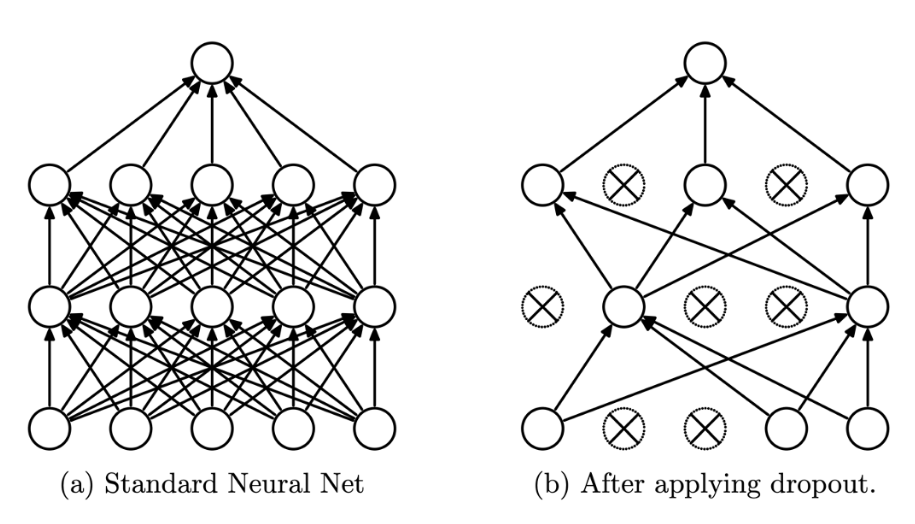

(GPT)
- 학습 과정에서 신경망 일부 뉴런을 확률적으로 제거(비활성화)하여 특정 뉴런에 의존하는 과적합을 줄이는 정규화 기법
  - 학습 시: 뉴런을 p 비율로 끔(drop)
  - 평가 시: 전체 뉴런 사용 + 활성값을 비례 보정
- 간단하게 말하면 학습할 때 뉴런을 일정 비율로 랜덤하게 끄고 평가할 때 뉴런을 100% 사용
- 목적
  - 과적합 방지
  - 특정 뉴런에 의존하지 않도록 해서 일반화 향상

### 학습과 추론 방식의 차이
- 드롭아웃은 학습에만 적용 $\leftarrow$ 학습하는 신경망에 노이즈 추가
- 추론에서는 모든 노드가 항상 참여해야 함

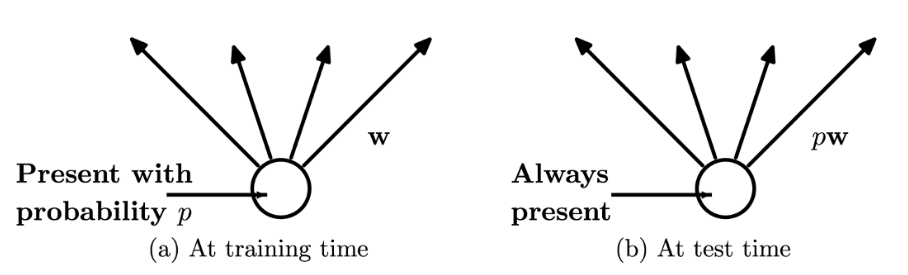

### 가중치에 (1-p)만큼 곱함
- 학습할 때 p 만큼의 확률로 드롭아웃을 하면 다음 계층으로 넘어가는 값은 드롭아웃을 하지 않을때에 비해 (1-p)배 크기로 작아지게 됨
  - 노드가 3개 있고 p=0.33이면 (1-p = 0.67)배, 즉 2개 노드의 값만큼 다음 단으로 값이 전달됨
- 그러나, 추론에서는 드롭아웃을 하지 않으므로 모든 노드 개수만큼의 값이 넘어가므로, 추론할 때는 (1-p)만큼 곱해주어야 학습할 떄의 값과 균형이 맞게 됨
- 파이토치에서는 반대로 학습할 때 미리 (1-p)만큼 나누어줌으로써 드롭아웃을 하지 않았을 때의 값의 크기로 환원시켜 주고, 추론할 때는 그냥 계산을 하도록 함

(GPT)
- 학습 시 드롭아웃을 적용하면 뉴런 일부가 꺼지므로 출력의 기대값이 (1-p)배로 줄어듦
- Original Dropout(초기 방식)
  - 학습 시: 스케일링 X
  - 추론 시: 출력 또는 가중치에 (1-p)를 곱해 학습 때와 출력 크기를 맞춤
- Inverted Dropout(파이토치 방식)
  - 학습 시: 남은 출력에 1/(1-p)를 곱해서 미리 보정
  - 추론 시: 스케일링 X(그냥 계산)

### 드롭아웃의 구현
- 활성함수와 다음 계층 사이에 구현

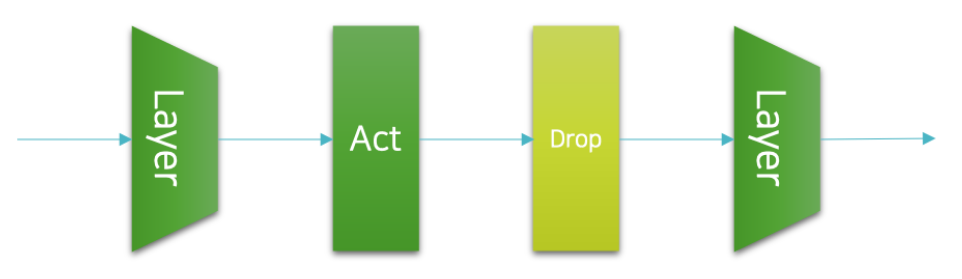

### 드롭아웃 장단점
- 장점: 일반화 성능 개선
- 단점
  - 손실값 수렴 속도가 저하될 수 있음 $\to$ 뉴런을 10개로 돌리는 것보다 7개로 돌리기 때문에 늦을 수 밖에 없음
  - 학습 오차가 증가할 수 있음
  - 드롭아웃 확률값(p)이 새로운 하이퍼파라미터로 추가됨

### 배치 정규화
- 공변량 변화(covariate shift) 문제 해결을 위해 제안됨
  - 공변량 문제: 둘 이상의 독립변수 또는 종속변수에 의해 결과가 영향을 받는 문제
  - 역전파로 파라미터 업데이트를 하여 최적화가 진행되었는데, 다음 입력 데이터는 이전 데이터와 다른 데이터이므로 최적화에 역행하는 출력을 산출할 수 있고 이것이 다음 계층으로 넘어가면서 다른 뉴런에 영향을 주게 됨
  - 이것이 공변량의 문제로 인식될 수 있음

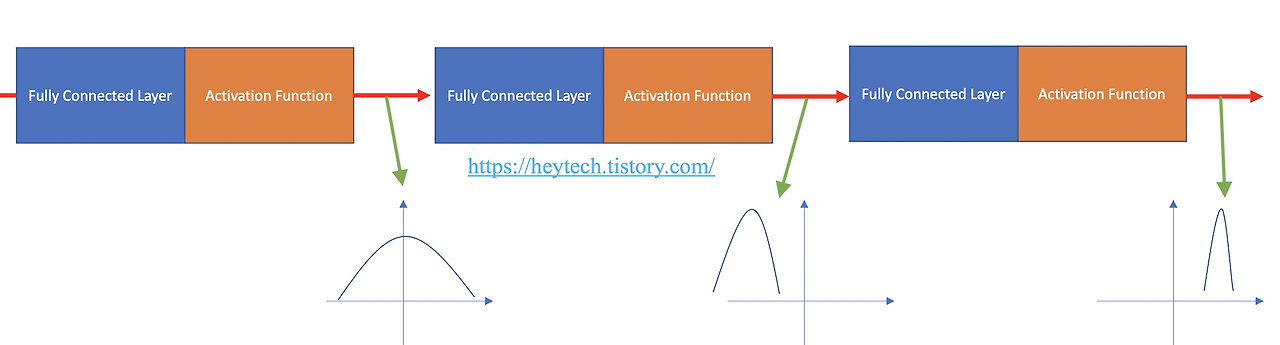

(GPT)
- 공변량 변화: 각 층의 입력 분포가 학습 과정 동안 계속 바뀌는 문제
  - 바뀌는 이유: 앞쪽 층의 가중치가 계속 업데이트되기 때문
  - 결과
    - 뒤쪽 층은 매 스텝마다 새로운 분포를 받아야 함
    - 학습이 불안정해짐
    - 더 작은 learning rate가 필요하게 됨
    - 수렴이 느려짐
- ex.
  - 레이어 A가 레이어 B로 데이터를 넘긴다고 가정
  - 학습이 진행되면서 레이어 A의 가중치가 계속 바뀜
  - 그럼 레이어 B가 받는 입력 분포도 계속 바뀜
- ex(수치)
  - 1 epoch 전: B는 평균 0.5, 분산 2.0인 입력을 받음
  - 가중치 업데이트 후: A의 weight 변화로 인해 B는 평균 1.7, 분산 5.8인 전혀 다른 분포를 받음
  - 또 업데이트 후: 이번엔 B가 평균 -0.3, 분산 1.1을 받음 $\to$ 매번 입력이 달라지는 환경이므로 학습을 안정적으로 하기 어려움
    - 이 현상을 ICS = Internal Covariate Shift라고 함

- 미니배치 분포를 정규화하여 해결

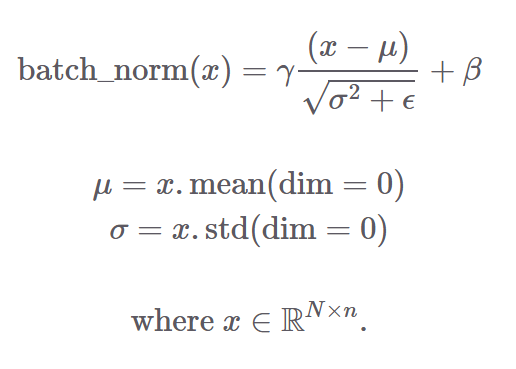
  - 미니배치를 단위 가우시안 분포로 바꾸는 정규표준분포화를 한 후,
  - 스케일 파라미터 $\gamma$와 이동 파라미터 $\beta$를 적용함
- 장점
  - 튜닝이 필요한 하이퍼파라미터가 추가되지 않음
  - 학습 속도 향상 + 일반화 성능 개선
  - 파라미터 초기화에 민감하지 않음
  - 학습률을 인위적으로 작게 유지할 필요 없음
- 한계
  - 동작 원리가 밝혀지지 않았음, 왜 좋아지는지 모름
  - 미니배치 크기가 너무 작거나 클 경우 효과가 떨어짐

### 배치정규화의 구현
- 논문 제시: 활성계층 앞에 위치

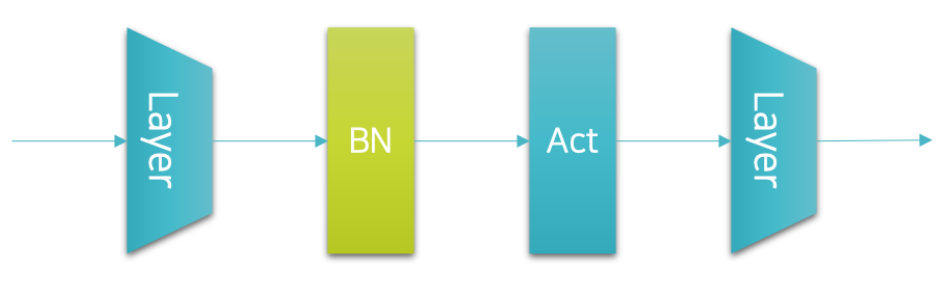
- 많은 경우: 드롭아웃 대신 사용하는 경우가 많아서 활성계층 다음에 위치

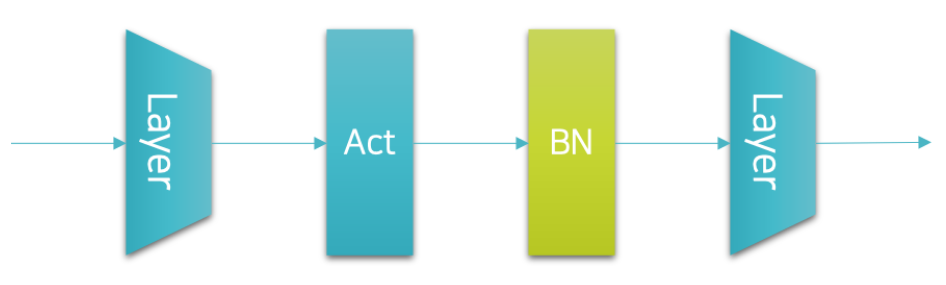

In [1]:
import numpy as np
from copy import deepcopy
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from torchvision import datasets, transforms

train = datasets.MNIST(
    '../data', train=True, download=True,
    transform=transforms.Compose([
        transforms.ToTensor(),
    ]),
)
test = datasets.MNIST(
    '../data', train=False,
    transform=transforms.Compose([
        transforms.ToTensor(),
    ]),
)

x = train.data.float() / 255.
y = train.targets

x = x.view(x.size(0), -1)
print(x.shape, y.shape)

input_size = x.size(-1)
output_size = int(max(y)) + 1

print('input_size: %d, output_size: %d' % (input_size, output_size))

ratios = [.8, .2]

train_cnt = int(x.size(0) * ratios[0])
valid_cnt = int(x.size(0) * ratios[1])
test_cnt = len(test.data)
cnts = [train_cnt, valid_cnt]

print("Train %d / Valid %d / Test %d samples." % (train_cnt, valid_cnt, test_cnt))

indices = torch.randperm(x.size(0))

x = torch.index_select(x, dim=0, index=indices)
y = torch.index_select(y, dim=0, index=indices)

x = list(x.split(cnts, dim=0))
y = list(y.split(cnts, dim=0))

x += [(test.data.float() / 255.).view(test_cnt, -1)]
y += [test.targets]

for x_i, y_i in zip(x, y):
    print(x_i.size(), y_i.size())

torch.Size([60000, 784]) torch.Size([60000])
input_size: 784, output_size: 10
Train 48000 / Valid 12000 / Test 10000 samples.
torch.Size([48000, 784]) torch.Size([48000])
torch.Size([12000, 784]) torch.Size([12000])
torch.Size([10000, 784]) torch.Size([10000])


### 모델 정의
- 선형 계층 + 비선형 계층 활성 함수 + 정규화 계층 $\to$ 서브 모듈(block)
  - 입출력 차원의크기만 다른 서브 모듈을 연결해서 사용
  - 하나의 클래스로 정의하여 사용 

In [2]:
class Block(nn.Module):
    
    def __init__(self,
                 input_size,
                 output_size,
                 use_batch_norm=True,
                 dropout_p=.4):
        self.input_size = input_size
        self.output_size = output_size
        self.use_batch_norm = use_batch_norm
        self.dropout_p = dropout_p
        
        super().__init__()
        
        def get_regularizer(use_batch_norm, size): # BatchNorm과 Dropout 중 하나를 선택해 붙이는 역할
            return nn.BatchNorm1d(size) if use_batch_norm else nn.Dropout(dropout_p)
        
        self.block = nn.Sequential(
            nn.Linear(input_size, output_size),
            nn.LeakyReLU(),
            get_regularizer(use_batch_norm, output_size),
        )
        
    def forward(self, x):
        # |x| = (batch_size, input_size)
        y = self.block(x)
        # |y| = (batch_size, output_size)
        
        return y

In [3]:
class MyModel(nn.Module): # MyModel이지만 사실 분류기에 가까움
    def __init__(self,
                 input_size,
                 output_size,
                 use_batch_norm=True,
                 dropout_p=.4):

        super().__init__()

        self.layers = nn. Sequential(
            Block(input_size, 500, use_batch_norm, dropout_p),
            Block(500, 400, use_batch_norm, dropout_p),
            Block(400, 300, use_batch_norm, dropout_p),
            Block(300, 200, use_batch_norm, dropout_p),
            Block(200, 100, use_batch_norm, dropout_p),
            Block(100, 50, use_batch_norm, dropout_p),
            nn.Linear(50, output_size),
            nn.LogSoftmax(dim=-1),
        )
        
    def forward(self, x):
        # |x| = (batch_size, input_size)        
        y = self.layers(x)
        # |y| = (batch_size, output_size)
        
        return y

In [4]:
model = MyModel(input_size,
                output_size,
                use_batch_norm=True)

print(model)

MyModel(
  (layers): Sequential(
    (0): Block(
      (block): Sequential(
        (0): Linear(in_features=784, out_features=500, bias=True)
        (1): LeakyReLU(negative_slope=0.01)
        (2): BatchNorm1d(500, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (1): Block(
      (block): Sequential(
        (0): Linear(in_features=500, out_features=400, bias=True)
        (1): LeakyReLU(negative_slope=0.01)
        (2): BatchNorm1d(400, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (2): Block(
      (block): Sequential(
        (0): Linear(in_features=400, out_features=300, bias=True)
        (1): LeakyReLU(negative_slope=0.01)
        (2): BatchNorm1d(300, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (3): Block(
      (block): Sequential(
        (0): Linear(in_features=300, out_features=200, bias=True)
        (1): LeakyReLU(negative_slope=0.01)
        (2): BatchNorm1d(200, e

In [5]:
optimizer = optim.Adam(model.parameters())
crit = nn.NLLLoss()

device = torch.device('cpu')
if torch.cuda.is_available():
    device = torch.device('cuda')

model = model.to(device)

x = [x_i.to(device) for x_i in x]
y = [y_i.to(device) for y_i in y]

n_epochs = 1000
batch_size = 256
print_interval = 10

lowest_loss = np.inf
best_model = None

early_stop = 50
lowest_epoch = np.inf

train_history, valid_history = [], []

for i in range(n_epochs):
    model.train()
    
    indices = torch.randperm(x[0].size(0)).to(device)
    x_ = torch.index_select(x[0], dim=0, index=indices)
    y_ = torch.index_select(y[0], dim=0, index=indices)
    
    x_ = x_.split(batch_size, dim=0)
    y_ = y_.split(batch_size, dim=0)
    
    train_loss, valid_loss = 0, 0
    y_hat = []
    
    for x_i, y_i in zip(x_, y_):
        y_hat_i = model(x_i)
        loss = crit(y_hat_i, y_i.squeeze())

        optimizer.zero_grad()
        loss.backward()

        optimizer.step()        
        train_loss += float(loss)

    train_loss = train_loss / len(x_)
        
    model.eval()
    with torch.no_grad():
        x_ = x[1].split(batch_size, dim=0)
        y_ = y[1].split(batch_size, dim=0)
        
        valid_loss = 0
        
        for x_i, y_i in zip(x_, y_):
            y_hat_i = model(x_i)
            loss = crit(y_hat_i, y_i.squeeze())
            
            valid_loss += float(loss)
            
            y_hat += [y_hat_i]
            
    valid_loss = valid_loss / len(x_)
    
    train_history += [train_loss]
    valid_history += [valid_loss]
        
    if (i + 1) % print_interval == 0:
        print('Epoch %d: train loss=%.4e  valid_loss=%.4e  lowest_loss=%.4e' % (
            i + 1,
            train_loss,
            valid_loss,
            lowest_loss,
        ))
        
    if valid_loss <= lowest_loss:
        lowest_loss = valid_loss
        lowest_epoch = i
        
        best_model = deepcopy(model.state_dict())
    else:
        if early_stop > 0 and lowest_epoch + early_stop < i + 1:
            print("There is no improvement during last %d epochs." % early_stop)
            break

print("The best validation loss from epoch %d: %.4e" % (lowest_epoch + 1, lowest_loss))
model.load_state_dict(best_model)

C:\Users\legna\AppData\Local\Temp\ipykernel_22092\929795071.py:46: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:836.)
  train_loss += float(loss)


Epoch 10: train loss=2.1338e-02  valid_loss=7.7625e-02  lowest_loss=7.4380e-02
Epoch 20: train loss=1.2826e-02  valid_loss=8.1384e-02  lowest_loss=7.4380e-02
Epoch 30: train loss=1.0260e-02  valid_loss=8.8456e-02  lowest_loss=7.4380e-02
Epoch 40: train loss=6.3437e-03  valid_loss=8.6847e-02  lowest_loss=7.4380e-02
Epoch 50: train loss=4.7403e-03  valid_loss=8.8055e-02  lowest_loss=7.4380e-02
There is no improvement during last 50 epochs.
The best validation loss from epoch 9: 7.4380e-02


<All keys matched successfully>

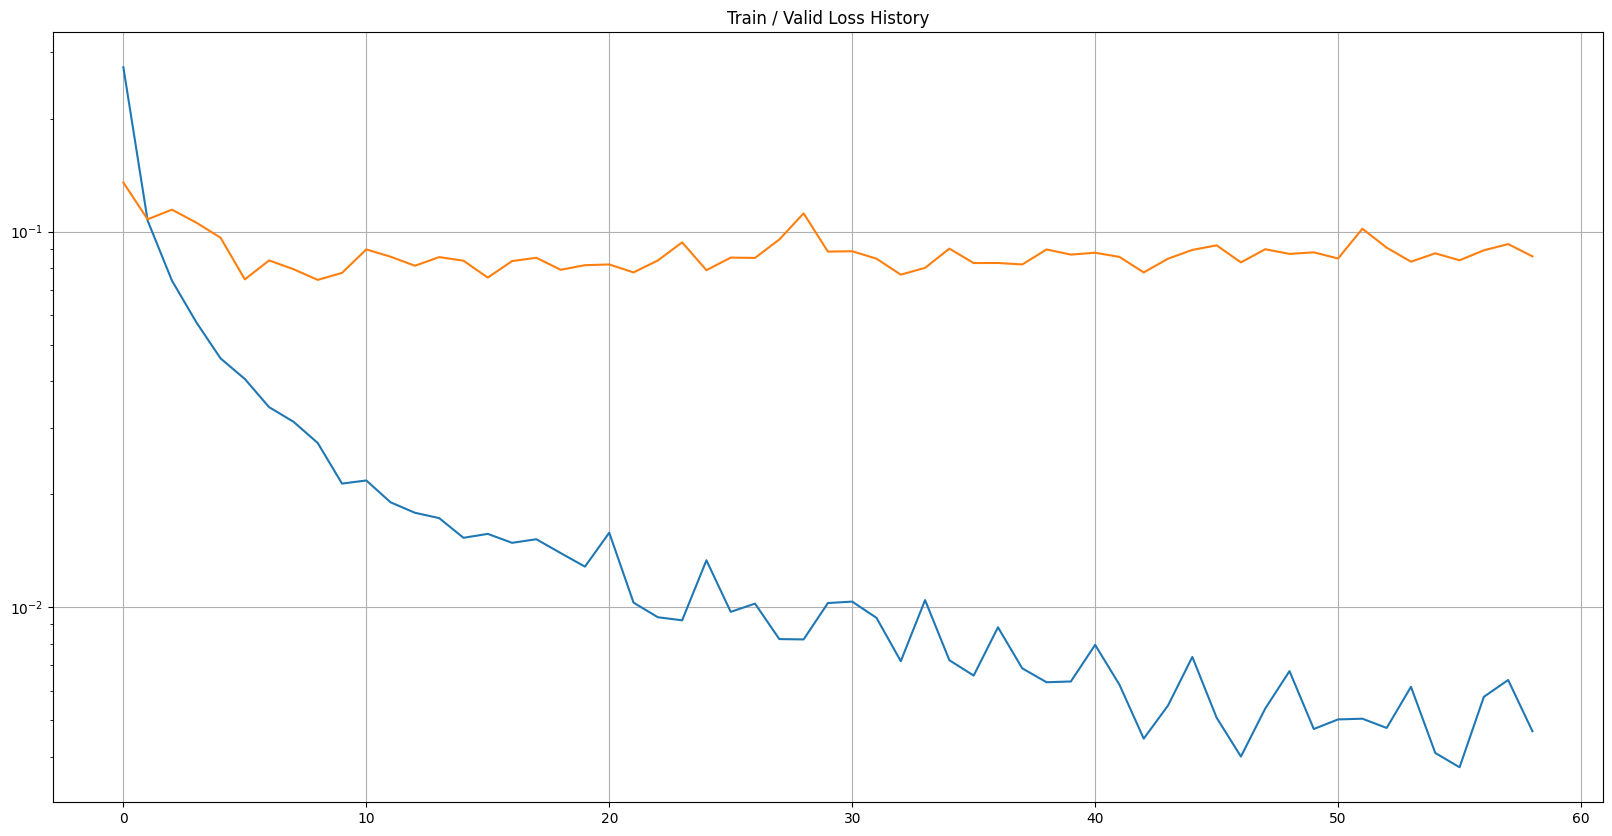

In [6]:
plot_from = 0

plt.figure(figsize=(20, 10))
plt.grid(True)
plt.title("Train / Valid Loss History")
plt.plot(
    range(plot_from, len(train_history)), train_history[plot_from:],
    range(plot_from, len(valid_history)), valid_history[plot_from:],
)
plt.yscale('log')
plt.show()

In [7]:
test_loss = 0
y_hat = []

model.eval()
with torch.no_grad():
    x_ = x[-1].split(batch_size, dim=0)
    y_ = y[-1].split(batch_size, dim=0)

    for x_i, y_i in zip(x_, y_):
        y_hat_i = model(x_i)
        loss = crit(y_hat_i, y_i.squeeze())

        test_loss += loss # Gradient is already detached.

        y_hat += [y_hat_i]

test_loss = test_loss / len(x_)
y_hat = torch.cat(y_hat, dim=0)

print("Test Loss: %.4e" % test_loss)

correct_cnt = (y[-1].squeeze() == torch.argmax(y_hat, dim=-1)).sum()
total_cnt = float(y[-1].size(0))

print('Test Accuracy: %.4f' % (correct_cnt / total_cnt))

Test Loss: 6.6972e-02
Test Accuracy: 0.9820


In [8]:
import pandas as pd
from sklearn.metrics import confusion_matrix

pd.DataFrame(confusion_matrix(y[-1], torch.argmax(y_hat, dim=-1)),
             index=['true_%d' % i for i in range(10)],
             columns=['pred_%d' % i for i in range(10)])

,pred_0,pred_1,pred_2,pred_3,pred_4,pred_5,pred_6,pred_7,pred_8,pred_9
true_0,968,0,1,1,0,1,5,2,2,0
true_1,0,1131,0,1,0,1,1,0,1,0
true_2,2,4,1006,7,0,0,2,5,4,2
true_3,0,0,3,997,0,3,0,1,6,0
true_4,0,0,2,1,962,1,4,2,2,8
true_5,2,1,0,6,1,870,5,0,6,1
true_6,2,3,0,1,3,2,944,0,3,0
true_7,1,5,6,7,0,0,0,1004,2,3
true_8,0,0,2,1,0,1,1,4,964,1
true_9,2,2,1,8,9,2,1,1,9,974


### model.train(), model.eval(), model.no_grad(), p.requires_grad=False의 용도 구별
- model.train()
  - forward 연산
  - Batch Normalization Layer $\to$ batch statistics를 이용하여 연산
  - Dropout Layer $\to$ 주어진 비율로 활성화
  - backward 연산 가능 
- model.eval()
  - forward 연산
  - Batch Normalization Layer $\to$ 학습에서 결정된 running statistics로 연산
  - Dropout Layer $\to$ 비활성화
  - backward 연산 가능 
- model.no_grad()
  - forward 연산
  - Batch Normalization Layer $\to$ batch statistics를 이용하여 연산
  - autograd 엔진 비활성화 $\to$ backward 연산 불가 $\to$ 메모리 효율성 향상, 속도 향상
- requires_grad=False
  - 설정한 파라미터는 gradient 연산을 하지 않음
  - model.no_grad()는 전체 파라미터의 gradient 연산을 하지 않는 것에 반해, 설정한 파라미터만 gradient 연산을 하지 않음
  - model.no_grad()는 autograd 엔진이 비활성화되기 때문에 gradient를 저장하지 않지만, 이 경우에느 연산만 하지 않을 뿐 gradient를 저장함
  - 모델의 특정 부분을 freeze시키고 나머지 부분만 학습시키는 역할 수행

### 실무 환경에서의 프로젝트 연습
- 튜닝 작업은 같은 코드로 하이퍼파라미터 변경 후 시험 반복 $\to$ 커맨더 창에서 스크립트 실행이 편리함
  - 주피터 노트북 실습 $\to$ 파이썬 파일(.py)로 변경하여 프로젝트 파일로 실행

### 머신러닝 프로젝트 파일 구조
- model.py: 모델 클래스 정의
- trainer.py: 모델 학습을 위한 트레이터 정의
- dataload.py: 데이터 로딩, 전처리 수행
- train.py: 하이퍼파라미터를 입력받아서 학습 진행
- predict.py: 학습된 모델과 추론용 샘플을 입력받아서 추론 수행<br>
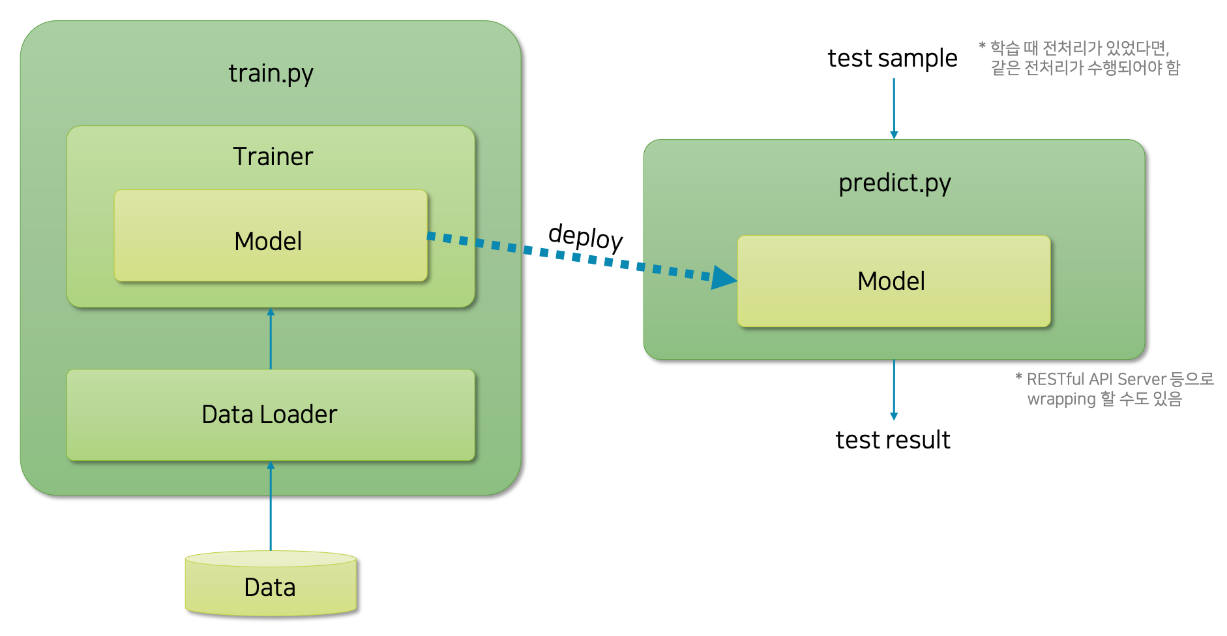

- train.py를 통해 코드 수정없이 다양한 하이퍼파라미터를 변경해가며 반복적인 실험을 수행
- 프로그램은 하이퍼 파라미터를 넘겨받아 코드 수정없이 수행되도록 구현

In [ ]:
>>> python train.py --model_fn ./model/model.pth --n_layers 10 __dropout 0.3

### 신경망 구조 결정 과정
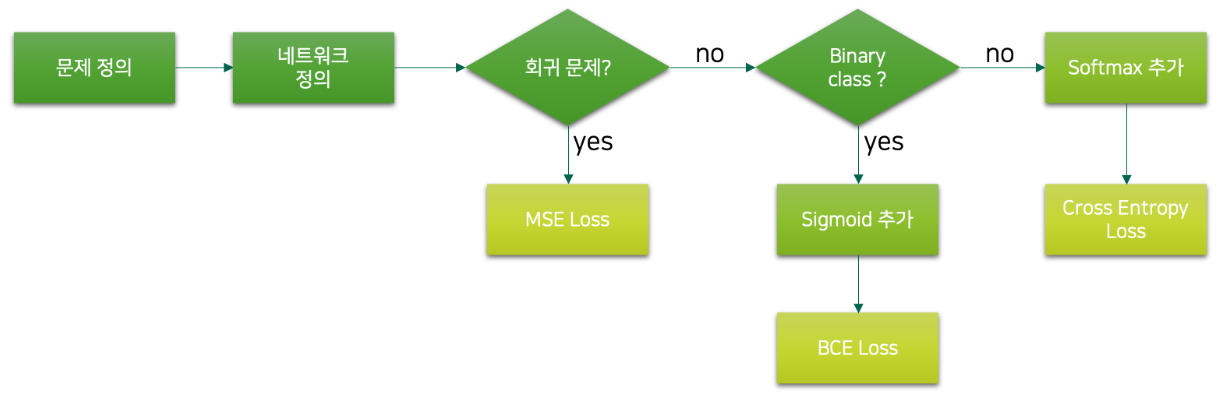

## 실습 소개
### 모델 구조 설계
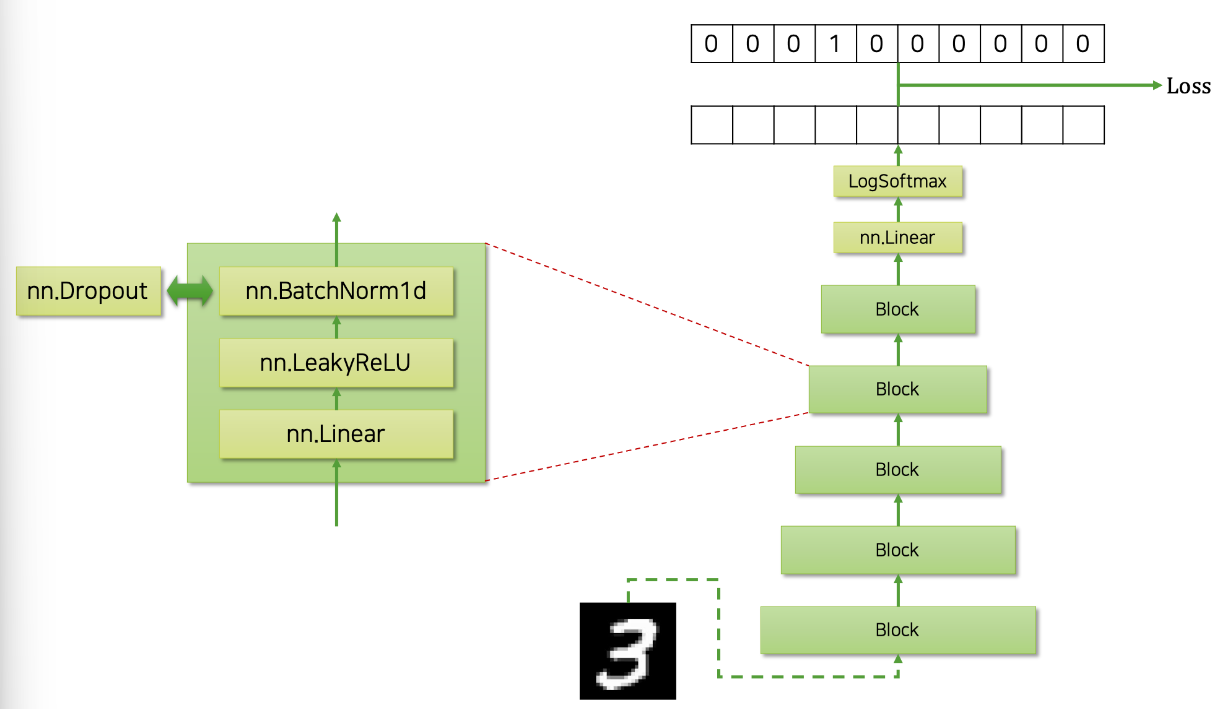

### 학습 과정
- 1 epoch의 과정
  - Training
    - Iteration 시작 $\to$ feed forward $\to$ Loss 계산 $\to$ Backpropagation $\to$ Gradient Desent 수행 $\to$ 현재 상태 출력 $\to$ Iteration 종료
  - Validation
    - Iteration 시작 $\to$ feed forward $\to$ Loss 계산 $\to$ 현재 상태 출력 $\to$ Iteration 종료
  - Best loss 체크 $\to$ 모델 저장

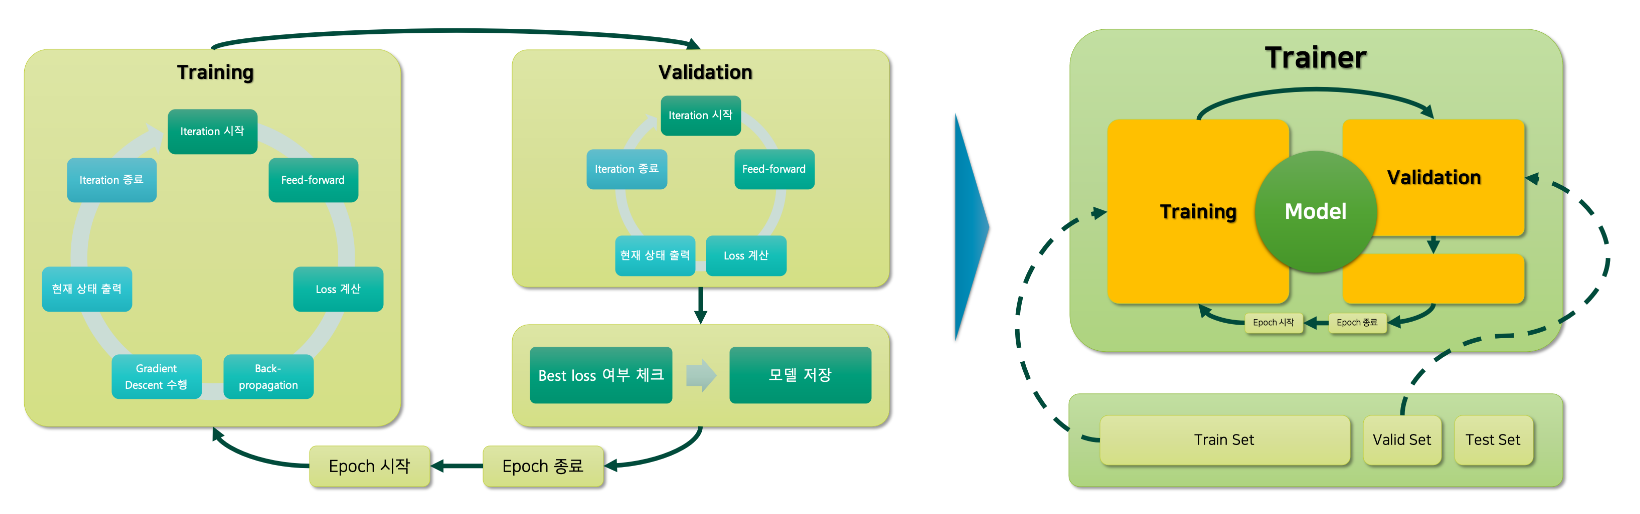

### 파일 구조
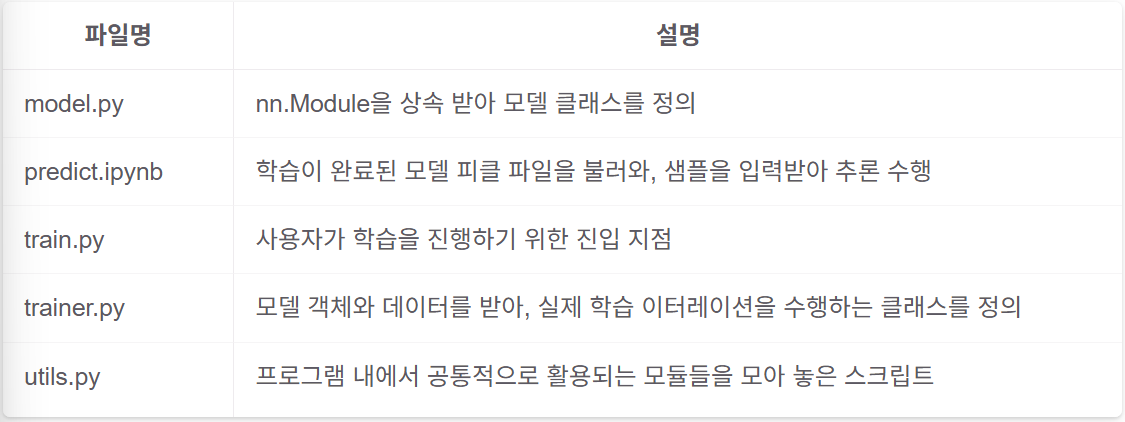
- 향후 디렉토리 구조를 추가하여 효율적으로 관리
- 컨볼루션신경망(CNN), 순환신경망(RNN)이 추가될 예정

## 실습
### 분류기 모델 구현

In [9]:
import torch
import torch.nn as nn

class Block(nn.Module): # MLP의 기본 단위 Layer Block 구성을 담당하는 모듈(선형 -> 활성화(ReLU) -> BatchNorm/Dropout)
    
    def __init__(self,
                 input_size,
                 output_size,
                 use_batch_norm=True,
                 dropout_p=.4):
        self.input_size = input_size
        self.output_size = output_size
        self.use_batch_norm = use_batch_norm
        self.dropout_p = dropout_p
        
        super().__init__()


        # use_batch_norm=True -> nn.BatchNorm1d, False -> nn.Dropout(dtopout_p) // 둘 중 택 1
        def get_regularizer(use_batch_norm, size):
            return nn.BatchNorm1d(size) if use_batch_norm else nn.Dropout(dropout_p)
        
        self.block = nn.Sequential(
            nn.Linear(input_size, output_size), # W, b 파라미터
            nn.LeakyReLU(),  # 활성화 함수
            get_regularizer(use_batch_norm, output_size),
        )
        
    def forward(self, x):  # 입력 x를 통과시켜 출력 y 반환
        # |x| = (batch_size, input_size)
        y = self.block(x)
        # |y| = (batch_size, output_size)
        
        return y

    
class ImageClassifier(nn.Module): # Hidden Layer들을 적충하여 전체 MLP 모델 구성

    def __init__(self,
                 input_size,
                 output_size,
                 hidden_sizes=[500, 400, 300, 200, 100],  # 리스트를 통해 여러 Block 연결
                 use_batch_norm=True,
                 dropout_p=.3):
        
        super().__init__()

        assert len(hidden_sizes) > 0, "You need to specify hidden layers"

        last_hidden_size = input_size
        blocks = []
        for hidden_size in hidden_sizes:  # 히든층 여러개 쌓기
            blocks += [Block(
                last_hidden_size,
                hidden_size,
                use_batch_norm,
                dropout_p
            )]
            last_hidden_size = hidden_size
        
        self.layers = nn.Sequential(
            # 리스트 안에 있는 객체들을 하나씩 꺼내서 Sequential의 인자로 전달
            # blocks = [Block(784→500), Block(500→400), Block(400→300), ... ]
            *blocks,
            nn.Linear(last_hidden_size, output_size),
            nn.LogSoftmax(dim=-1),  # NLLLoss용 확률 로그 출력
        )
        
    def forward(self, x):
        # |x| = (batch_size, input_size)        
        y = self.layers(x)  # 입력 x를 연속적으로 은닉층과 출력층에 통과시킴
        # |y| = (batch_size, output_size)
        
        return y

### 데이터 로딩(utils.py) 구현

In [10]:
import torch


def load_mnist(is_train=True, flatten=True):  # MNIST 로드 + 전처리
    from torchvision import datasets, transforms

    # MNIST 로딩
    dataset = datasets.MNIST(
        '../data', train=is_train, download=True,
        transform=transforms.Compose([
            transforms.ToTensor(),
        ]),
    )
    # 픽셀값 정규화 0~1
    x = dataset.data.float() / 255.
    y = dataset.targets

    # flatten=True 이면 28x28 -> 784차원 벡터
    if flatten:
        x = x.view(x.size(0), -1)

    return x, y

# 데이터 분할 알고리즘(섞고 Train/Valid 나누기)
def split_data(x, y, train_ratio=.8): # 80%는 학습, 나머지 20%가 검증
    train_cnt = int(x.size(0) * train_ratio)
    valid_cnt = x.size(0) - train_cnt

    # 랜덤 셔플
    indices = torch.randperm(x.size(0))
    x = torch.index_select(
        x,
        dim=0,
        index=indices
    ).split([train_cnt, valid_cnt], dim=0)
    y = torch.index_select(
        y,
        dim=0,
        index=indices
    ).split([train_cnt, valid_cnt], dim=0)

    return x, y

# 은닉층 사이즈를 자동 계산하는 알고리즘
def get_hidden_sizes(input_size, output_size, n_layers):
    step_size = int((input_size - output_size) / n_layers) # 계단식 크기 감소

    hidden_sizes = [] # 리스트 생성, 각 층 크기 반
    current_size = input_size
    for i in range(n_layers - 1):
        hidden_sizes += [current_size - step_size]
        current_size = hidden_sizes[-1]

    return hidden_sizes
    
# ex) input = 784, output = 10, n_layers = 6
#     step = (784 - 10) / 6 = 129
#     히든 층: 784 -> 655 -> 526 -> 397 -> 268 -> 139

### 트레이너 클래스 구현
- config에 저장 후 trianer에 줌

In [11]:
from copy import deepcopy
import numpy as np

import torch

# 배치 분할, forward, backward, optimizer step 등 훈련 전체 관
class Trainer():

    def __init__(self, model, optimizer, crit):
        self.model = model
        self.optimizer = optimizer
        self.crit = crit

        super().__init__()

    # 데이터를 배치 단위로 나누고, 필요시 랜덤 셔플
    def _batchify(self, x, y, batch_size, random_split=True):
        if random_split:
            indices = torch.randperm(x.size(0), device=x.device)
            x = torch.index_select(x, dim=0, index=indices)
            y = torch.index_select(y, dim=0, index=indices)

        x = x.split(batch_size, dim=0)
        y = y.split(batch_size, dim=0)

        return x, y

    # 학습용 루프
    def _train(self, x, y, config):
        self.model.train() # 모델 학습 모드

        x, y = self._batchify(x, y, config.batch_size)
        total_loss = 0

        for i, (x_i, y_i) in enumerate(zip(x, y)):
            y_hat_i = self.model(x_i) # forward
            loss_i = self.crit(y_hat_i, y_i.squeeze()) # loss

            # backward
            self.optimizer.zero_grad()
            loss_i.backward()

            self.optimizer.step()

            if config.verbose >= 2:
                print("Train Iteration(%d/%d): loss=%.4e" % (i + 1, len(x), float(loss_i)))

            # Don't forget to detach to prevent memory leak.
            total_loss += float(loss_i)

        return total_loss / len(x)

    # 검증용 루프
    def _validate(self, x, y, config):
        # Turn evaluation mode on.
        self.model.eval()

        # validation
        with torch.no_grad():
            x, y = self._batchify(x, y, config.batch_size, random_split=False)
            total_loss = 0

            for i, (x_i, y_i) in enumerate(zip(x, y)):
                y_hat_i = self.model(x_i)
                loss_i = self.crit(y_hat_i, y_i.squeeze())

                if config.verbose >= 2:
                    print("Valid Iteration(%d/%d): loss=%.4e" % (i + 1, len(x), float(loss_i)))

                total_loss += float(loss_i)

            return total_loss / len(x)

    # 전체 epoch 학습
    def train(self, train_data, valid_data, config):
        lowest_loss = np.inf
        best_model = None

        for epoch_index in range(config.n_epochs):
            # train, validation loss 계산
            train_loss = self._train(train_data[0], train_data[1], config)
            valid_loss = self._validate(valid_data[0], valid_data[1], config)

            # best checkpoint 저장
            if valid_loss <= lowest_loss:
                lowest_loss = valid_loss
                best_model = deepcopy(self.model.state_dict()) # 가장 낮은 validation loss 모델 저장(deepcopy)

            print("Epoch(%d/%d): train_loss=%.4e  valid_loss=%.4e  lowest_loss=%.4e" % (
                epoch_index + 1,
                config.n_epochs,
                train_loss,
                valid_loss,
                lowest_loss,
            ))

        # Restore to best model.
        self.model.load_state_dict(best_model)

### train.py 구현

In [13]:
import argparse

import torch
import torch.nn as nn
import torch.optim as optim

from model import ImageClassifier
from trainer import Trainer

from utils import load_mnist
from utils import split_data
from utils import get_hidden_sizes

# 학습 파라미터를 명령줄로 받음
def define_argparser():
    p = argparse.ArgumentParser()

    p.add_argument('--model_fn', required=True) # 저장할 모델 파일
    p.add_argument('--gpu_id', type=int, default=0 if torch.cuda.is_available() else -1) # GPU 사용 여부

    p.add_argument('--train_ratio', type=float, default=.8)

    p.add_argument('--batch_size', type=int, default=256)
    p.add_argument('--n_epochs', type=int, default=20)

    p.add_argument('--n_layers', type=int, default=5)
    p.add_argument('--use_dropout', action='store_true')
    p.add_argument('--dropout_p', type=float, default=.3)

    p.add_argument('--verbose', type=int, default=1)

    config = p.parse_args()

    return config


def main(config):
    # 디바이스 설정
    device = torch.device('cpu') if config.gpu_id < 0 else torch.device('cuda:%d' % config.gpu_id)

    # 데이터 로드, split
    x, y = load_mnist(is_train=True, flatten=True)
    x, y = split_data(x.to(device), y.to(device), train_ratio=config.train_ratio)

    print("Train:", x[0].shape, y[0].shape)
    print("Valid:", x[1].shape, y[1].shape)

    input_size = int(x[0].shape[-1])
    output_size = int(max(y[0])) + 1

    # 모델 생성(ImageClassifier)
    model = ImageClassifier(
        input_size=input_size,
        output_size=output_size,
        hidden_sizes=get_hidden_sizes(input_size,
                                      output_size,
                                      config.n_layers),
        use_batch_norm=not config.use_dropout,
        dropout_p=config.dropout_p,
    ).to(device)

    # optimizer, loss 정의
    optimizer = optim.Adam(model.parameters())
    crit = nn.NLLLoss()

    if config.verbose >= 1:
        print(model)
        print(optimizer)
        print(crit)

    # Trainer 생성
    trainer = Trainer(model, optimizer, crit)

    # 학습 시작
    trainer.train(
        train_data=(x[0], y[0]),
        valid_data=(x[1], y[1]),
        config=config
    )

    # 학습 완료 후 best 모델 저장
    torch.save({
        'model': trainer.model.state_dict(),
        'opt': optimizer.state_dict(),
        'config': config,
    }, config.model_fn)


if __name__ == '__main__':
    config = define_argparser()
    main(config)

usage: ipykernel_launcher.py [-h] --model_fn MODEL_FN [--gpu_id GPU_ID] [--train_ratio TRAIN_RATIO]
                             [--batch_size BATCH_SIZE] [--n_epochs N_EPOCHS] [--n_layers N_LAYERS] [--use_dropout]
                             [--dropout_p DROPOUT_P] [--verbose VERBOSE]
ipykernel_launcher.py: error: the following arguments are required: --model_fn


SystemExit: 2

In [31]:
!python train.py --model_fn tmp.pth --gpu_id -1 --batch_size 256 --n_epoch 20 --n_layers 5

Train:  torch.Size([48000, 784]) torch.Size([48000])
Valid:  torch.Size([12000, 784]) torch.Size([12000])
ImageClassifier(
  (layers): Sequential(
    (0): Block(
      (block): Sequential(
        (0): Linear(in_features=784, out_features=630, bias=True)
        (1): LeakyReLU(negative_slope=0.01)
        (2): BatchNorm1d(630, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (1): Block(
      (block): Sequential(
        (0): Linear(in_features=630, out_features=476, bias=True)
        (1): LeakyReLU(negative_slope=0.01)
        (2): BatchNorm1d(476, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (2): Block(
      (block): Sequential(
        (0): Linear(in_features=476, out_features=322, bias=True)
        (1): LeakyReLU(negative_slope=0.01)
        (2): BatchNorm1d(322, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (3): Block(
      (block): Sequential(
        (0): Linear(in_feat

C:\Users\legna\venvs\ML\Scripts\ML\trainer.py:44: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:836.)
  total_loss += float(loss_i)


### predict.ipynb 구현

In [32]:
import torch
import torch.nn

import sys
import numpy as np
import matplotlib.pyplot as plt

from model import ImageClassifier

from utils import load_mnist
from utils import split_data
from utils import get_hidden_sizes

model_fn = "./tmp.pth"

device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

def load(fn, device):
    # d = torch.load(fn, map_location=device)
    d = torch.load(fn, map_location=device, weights_only=False)
    
    return d['model'], d['config']


def plot(x, y_hat):
    for i in range(x.size(0)):
        img = (np.array(x[i].detach().cpu(), dtype='float')).reshape(28,28)

        plt.imshow(img, cmap='gray')
        plt.show()
        print("Predict:", float(torch.argmax(y_hat[i], dim=-1)))


def test(model, x, y, to_be_shown=True):
    model.eval()
    
    with torch.no_grad():
        y_hat = model(x)

        correct_cnt = (y.squeeze() == torch.argmax(y_hat, dim=-1)).sum()
        total_cnt = float(x.size(0))
        
        accuracy = correct_cnt / total_cnt
        print("Accuracy: %.4f" % accuracy)
        
        if to_be_shown:
            plot(x, y_hat)

model_dict, train_config = load(model_fn, device)

# Load MNIST test set.
x, y = load_mnist(is_train=False)
x, y = x.to(device), y.to(device)

input_size = int(x.shape[-1])
output_size = int(max(y)) + 1

model = ImageClassifier(
    input_size=input_size,
    output_size=output_size,
    hidden_sizes=get_hidden_sizes(input_size,
                                  output_size,
                                  train_config.n_layers),
    use_batch_norm=not train_config.use_dropout,
    dropout_p=train_config.dropout_p,
).to(device)

model.load_state_dict(model_dict)

test(model, x, y, to_be_shown=False)

Accuracy: 0.9810


Accuracy: 1.0000


C:\Users\legna\AppData\Local\Temp\ipykernel_22092\2755956316.py:27: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  img = (np.array(x[i].detach().cpu(), dtype='float')).reshape(28,28)


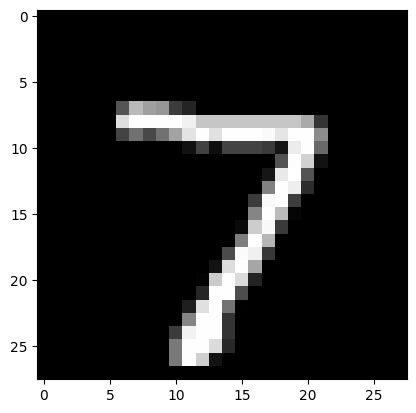

Predict: 7.0


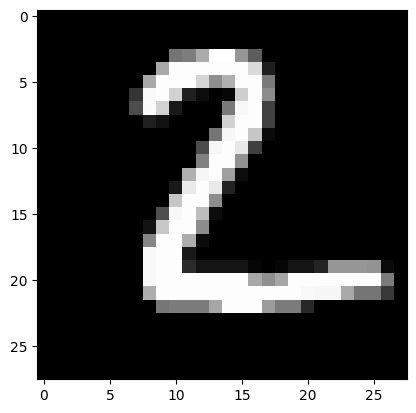

Predict: 2.0


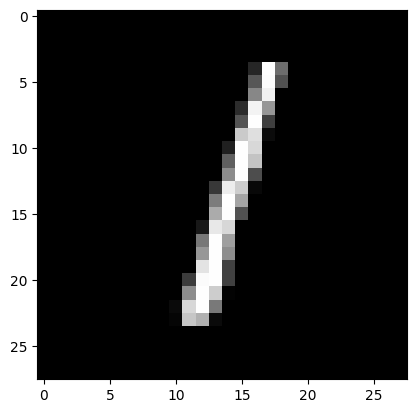

Predict: 1.0


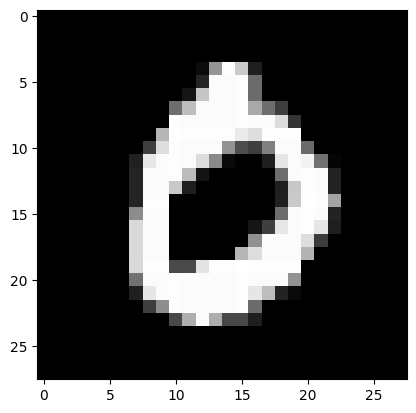

Predict: 0.0


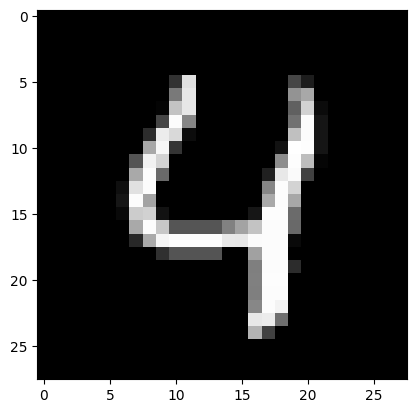

Predict: 4.0


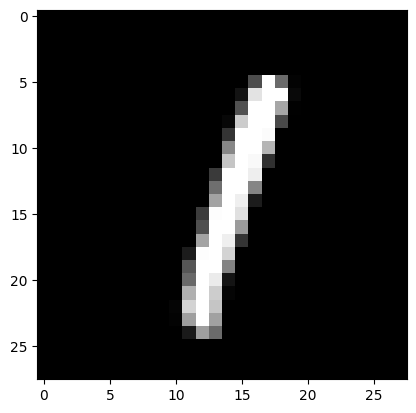

Predict: 1.0


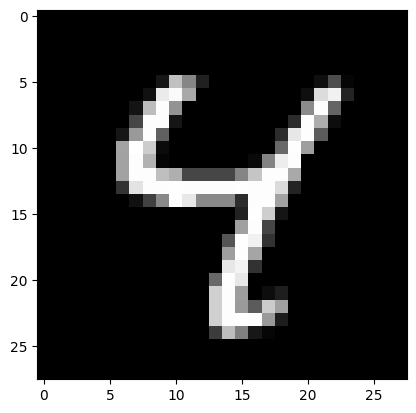

Predict: 4.0


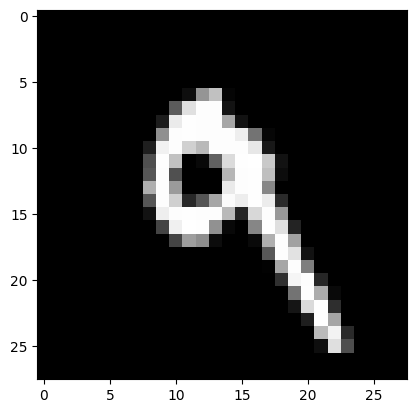

Predict: 9.0


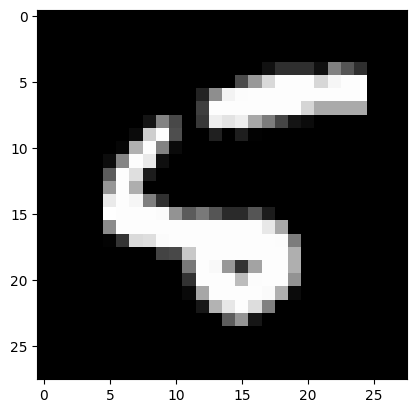

Predict: 5.0


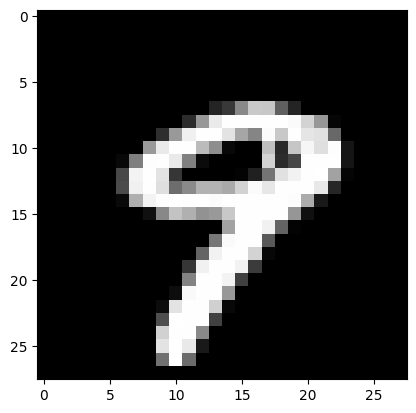

Predict: 9.0


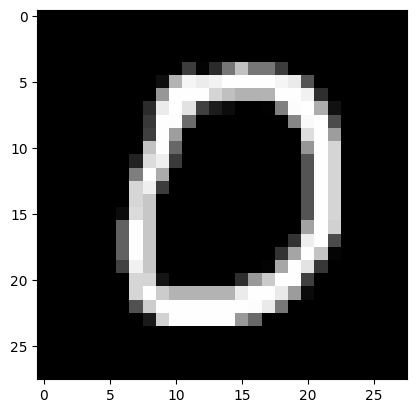

Predict: 0.0


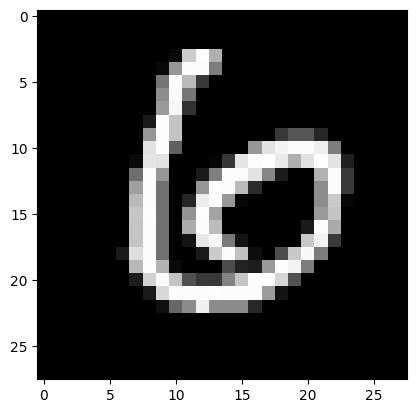

Predict: 6.0


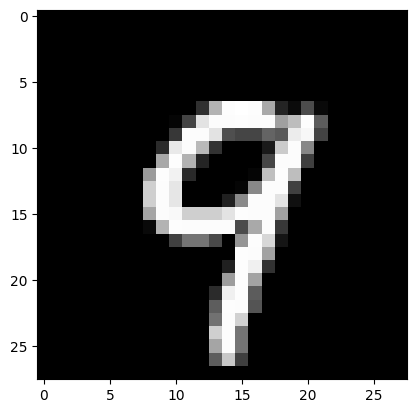

Predict: 9.0


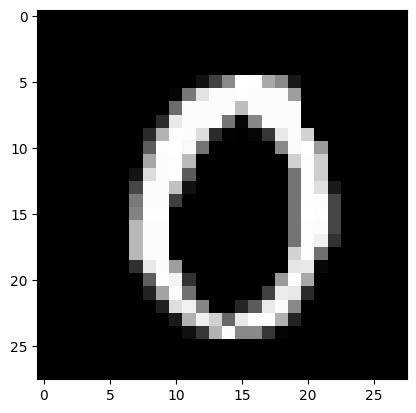

Predict: 0.0


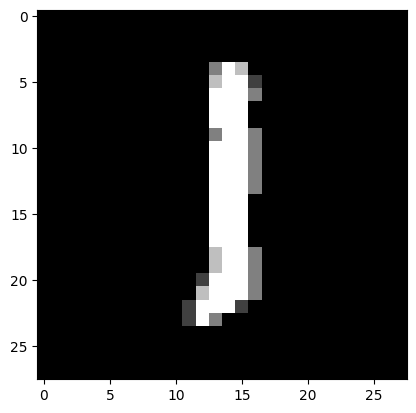

Predict: 1.0


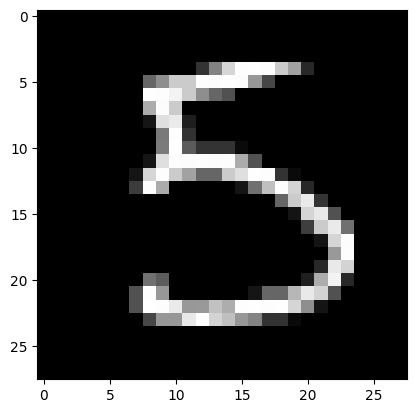

Predict: 5.0


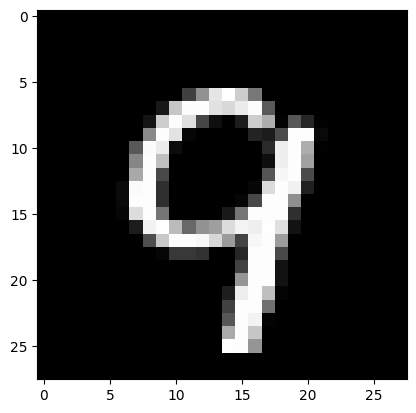

Predict: 9.0


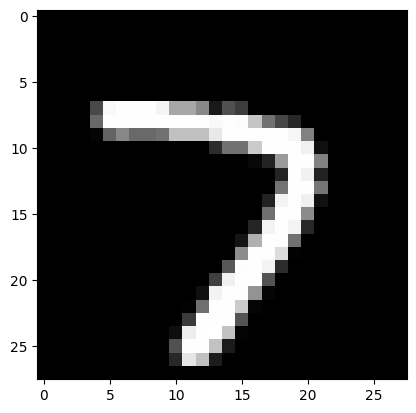

Predict: 7.0


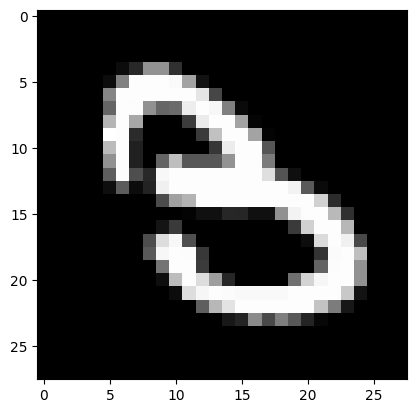

Predict: 3.0


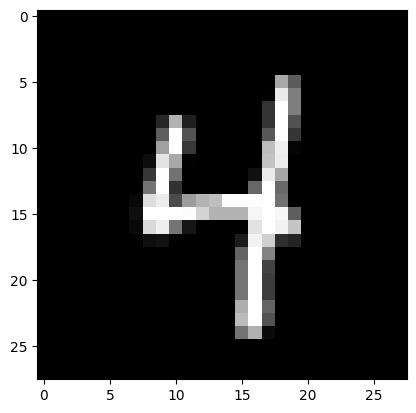

Predict: 4.0


In [33]:
n_test = 20
test(model, x[:n_test], y[:n_test], to_be_shown=True)